In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import spdiags

In [11]:
def cubic_spline(x, y):
    '''
    N. Melnikov, 2026

    s0, s1, s2, s3 = cubic_spline(x,y)

    Computes the coefficents of a cubic spline
    interpolant through the data points (x,y)

    The spline is defined as the piecewise cubic polynomial

           { Sk(x),    x(k) <= x <= x(k+1),
    S(x) = {
           { 0 ,       otherwise

    The cubic polynomial Sk(x) is given by

    Sk(x)  = sk0 + sk1*(x-x(k)) + sk2*(x-x(k))^2 + sk3*(x-x(k))^3

    The coefficents sk0, sk1, sk2, and sk3 of each of the polynomials
    are returned in the (row) vectors s0, s1, s2, s3, respectively.

    MATLAB source code https://gist.github.com/cmaes/1269709
    contains a bug describing "upper", which has been corrected
    in the Python code below
    '''
    if x.shape != y.shape or x.ndim != 1:
        raise ValueError('inputs x and y must be vectors of equal length')

    n = len(x)

    h = x[1:n] - x[0:n-1]
    d = (y[1:n] - y[0:n-1]) / h

    lower = h[1:]
    main = 2 * (h[:-1] + h[1:])
    upper = h[:-1]

    T = spdiags([lower, main, upper], [-1, 0, 1], n-2, n-2).toarray()
    print(f"h=\n{h}\nT=\n{T}")

    rhs = 6 * (d[1:] - d[:-1])

    m = np.linalg.solve(T, rhs)

    # Use natural boundary conditions, i.e. second derivative is zero at the endpoints
    m = np.hstack((0, m, 0))

    s0 = y[:-1]
    s1 = d - h * (2 * m[:-1] + m[1:]) / 6
    s2 = m / 2
    s3 = (m[1:] - m[:-1]) / (6 * h)

    return s0, s1, s2, s3

In [12]:
def plot_cubic_spline(x, s0, s1, s2, s3):
    '''
    plot_cubic_spline(x,s0,s1,s2,s3)

    plots a cubic spline with knots x
    and coefficents s0, s1, s2, s3
    '''
    n = len(x)
    inner_points = 20

    for i in range(n - 1):
        xx = np.linspace(x[i], x[i + 1], inner_points)
        yy = s0[i] + s1[i] * (xx - x[i]) + s2[i] * (xx - x[i]) ** 2 + s3[i] * (xx - x[i]) ** 3
        plt.plot(xx, yy, 'b--', linewidth=2)
        plt.scatter(x[i], 0, color='k')
    plt.scatter(x[-1], 0, color='k')
    plt.ylim(-0.1, 1.1)
    plt.xlim(x[0], x[-1])
    plt.show()

In [13]:
def runge(x):
    return 1 / (1 + 25 * x**2)

In [14]:
def cubic_driver(num_points):
    '''
    cubic_driver(n) computes a cubic spline
    interpolant of the runge function

    f(x) = 1/(1 + 25*x^2)

    based on num_points linearly spaced
    points in the interval [-1,1]
    '''
    x = np.linspace(-1, 1, num_points)
    y = runge(x)

    s0, s1, s2, s3 = cubic_spline(x, y)

    plot_points = 1000
    xx = np.linspace(-1, 1, plot_points)
    yy = runge(xx)
    plt.plot(xx, yy, 'r', linewidth=2)

    plot_cubic_spline(x, s0, s1, s2, s3)


h=
[0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2]
T=
[[0.8 0.2 0.  0.  0.  0.  0.  0.  0. ]
 [0.2 0.8 0.2 0.  0.  0.  0.  0.  0. ]
 [0.  0.2 0.8 0.2 0.  0.  0.  0.  0. ]
 [0.  0.  0.2 0.8 0.2 0.  0.  0.  0. ]
 [0.  0.  0.  0.2 0.8 0.2 0.  0.  0. ]
 [0.  0.  0.  0.  0.2 0.8 0.2 0.  0. ]
 [0.  0.  0.  0.  0.  0.2 0.8 0.2 0. ]
 [0.  0.  0.  0.  0.  0.  0.2 0.8 0.2]
 [0.  0.  0.  0.  0.  0.  0.  0.2 0.8]]


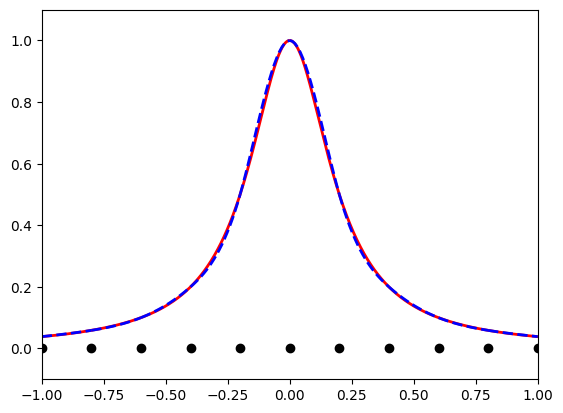

In [15]:
cubic_driver(11)

In [16]:
def cubic_driver_Cheb(num_points):
    '''
    cubic_driver(n) computes a cubic spline
    interpolant of the runge function

    f(x) = 1/(1 + 25*x^2)

    based on Chebyshev nodes in the interval [-1,1]
    '''
    t = np.linspace(0, np.pi, num_points)
    x_data = np.cos(t)  # proxi for N + 1 Chebyshev nodes
    y_data = runge(x_data)

    s0, s1, s2, s3 = cubic_spline(x_data, y_data)

    plot_points = 1000
    xx = np.linspace(-1, 1, plot_points)
    yy = runge(xx)
    plt.plot(xx, yy, 'r', linewidth=2)

    plot_cubic_spline(x_data, s0, s1, s2, s3)

h=
[-0.1339746 -0.3660254 -0.5       -0.5       -0.3660254 -0.1339746]
T=
[[-1.         -0.3660254   0.          0.          0.        ]
 [-0.3660254  -1.73205081 -0.5         0.          0.        ]
 [ 0.         -0.5        -2.         -0.5         0.        ]
 [ 0.          0.         -0.5        -1.73205081 -0.3660254 ]
 [ 0.          0.          0.         -0.3660254  -1.        ]]


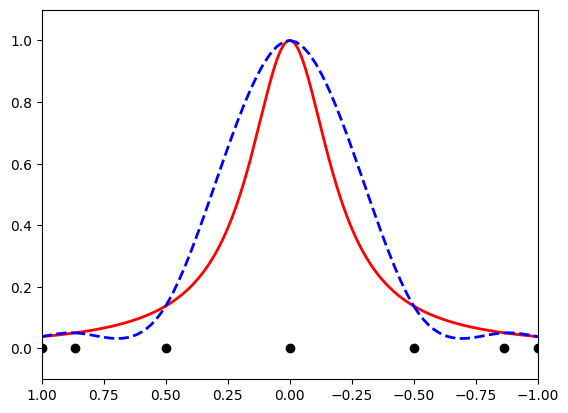

In [18]:
cubic_driver_Cheb(7)